# Projection Quality: Preliminary Distributions
Violin plots comparing PCA and UMAP across all datasets for four quality metrics.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dr_landscape.storage import results_to_dataframe

df = results_to_dataframe(results_dir="../results")
df.head()

,dataset,algorithm,metric,value
0,blobs,pca,average_local_error,0.057840
1,blobs,pca,class_aware_continuity,0.963027
2,blobs,pca,continuity,0.963027
3,blobs,pca,jaccard,0.026525
4,blobs,pca,mrre_data,0.069365


/tmp/ipykernel_415185/3265697925.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_415185/3265697925.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_415185/3265697925.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["PCA", "UMAP"])
/tmp/ipykernel_415185/3265697925.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_415185/3265697925.py:40: FutureWarning: 

Passing `palett

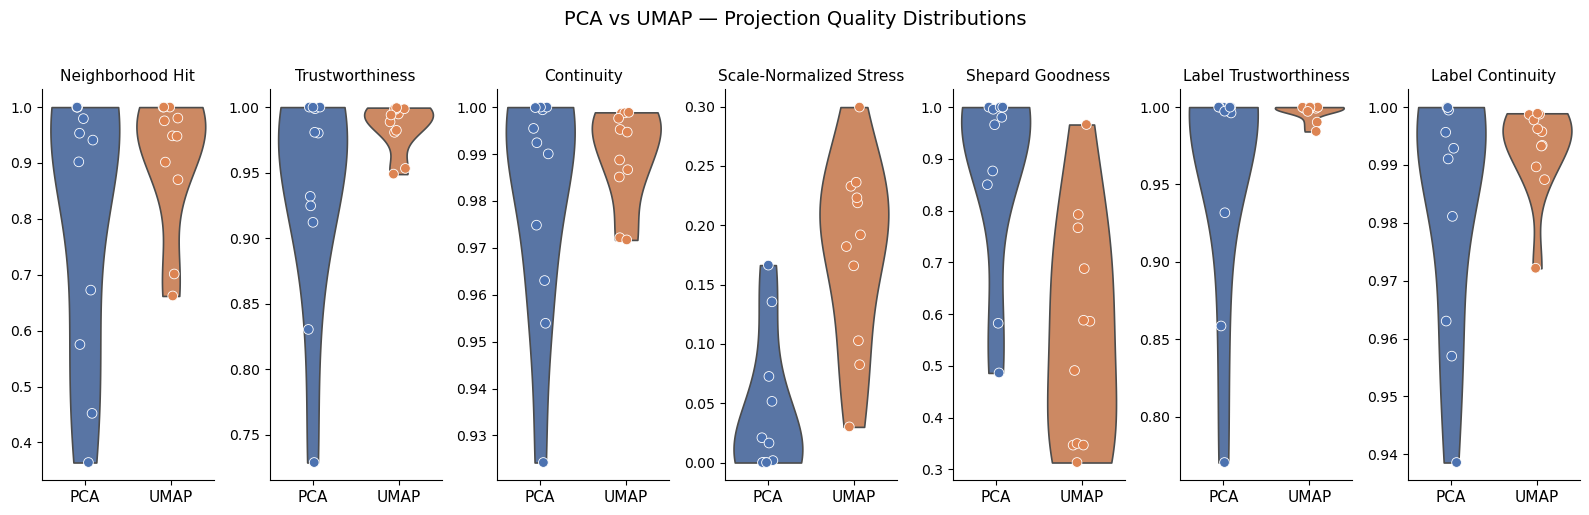

In [4]:
METRICS = [
    "neighborhood_hit",
    "trustworthiness",
    "continuity",
    "scale_normalized_stress",
    "shepard_goodness", 
    "class_aware_trustworthiness", 
    "class_aware_continuity", 
]

METRIC_LABELS = {
    "neighborhood_hit": "Neighborhood Hit",
    "trustworthiness": "Trustworthiness",
    "continuity": "Continuity",
    "scale_normalized_stress": "Scale-Normalized Stress",
    "shepard_goodness": "Shepard Goodness",
    "class_aware_trustworthiness": "Label Trustworthiness", 
    "class_aware_continuity": "Label Continuity"
}

PALETTE = {"pca": "#4C72B0", "umap": "#DD8452"}

plot_df = df[df["metric"].isin(METRICS)].copy()

fig, axes = plt.subplots(1, len(METRICS), figsize=(16, 5))
fig.suptitle("PCA vs UMAP — Projection Quality Distributions", fontsize=14, y=1.02)

for ax, metric in zip(axes, METRICS):
    data = plot_df[plot_df["metric"] == metric]

    sns.violinplot(
        data=data,
        x="algorithm", y="value",
        palette=PALETTE,
        inner=None,
        cut=0,
        linewidth=1.2,
        ax=ax,
    )
    sns.stripplot(
        data=data,
        x="algorithm", y="value",
        palette=PALETTE,
        size=7,
        jitter=True,
        linewidth=0.6,
        edgecolor="white",
        ax=ax,
    )

    ax.set_title(METRIC_LABELS[metric], fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=11)
    ax.set_xticklabels(["PCA", "UMAP"])
    sns.despine(ax=ax)

fig.tight_layout()
plt.savefig("distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### Per-dataset breakdown
Same metrics, but with dataset labels annotated on each point.

/tmp/ipykernel_415185/2170524535.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_415185/2170524535.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_415185/2170524535.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_415185/2170524535.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


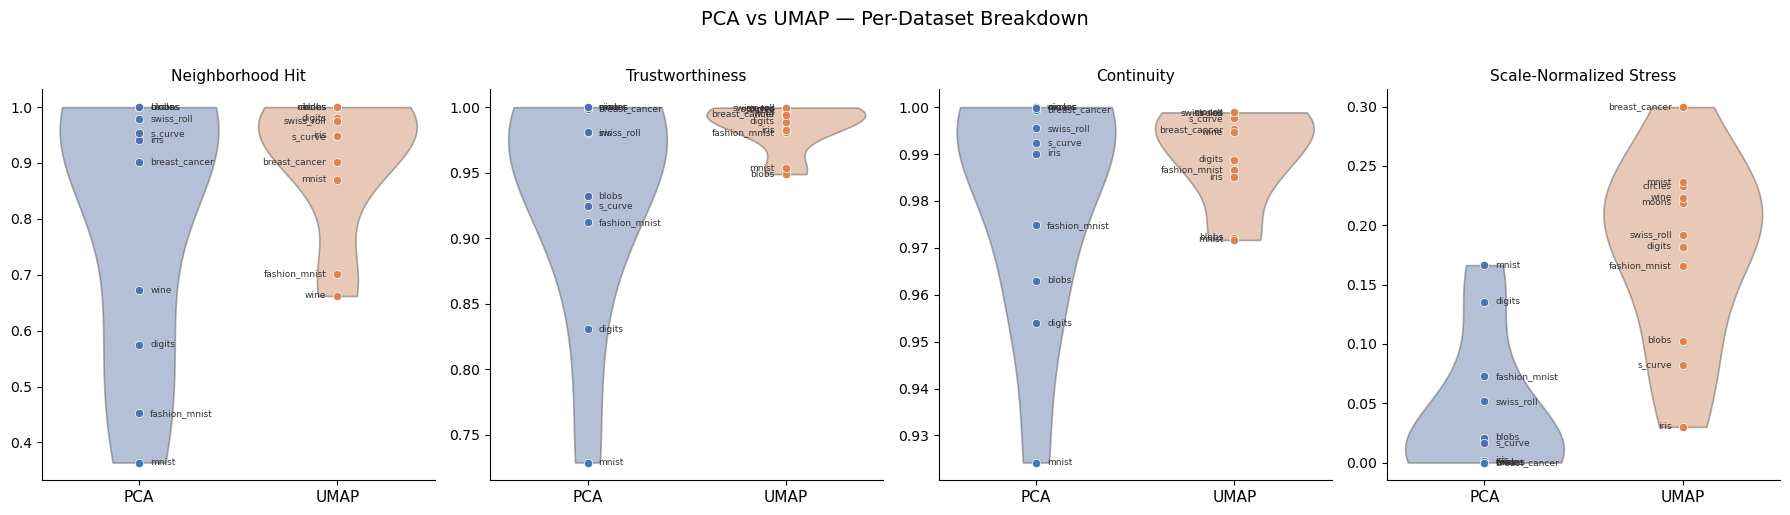

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("PCA vs UMAP — Per-Dataset Breakdown", fontsize=14, y=1.02)

for ax, metric in zip(axes, METRICS):
    data = plot_df[plot_df["metric"] == metric]

    sns.violinplot(
        data=data,
        x="algorithm", y="value",
        palette=PALETTE,
        inner=None,
        cut=0,
        linewidth=1.2,
        alpha=0.45,
        ax=ax,
    )

    # Annotate each dot with dataset name
    algo_order = [t.get_text() for t in ax.get_xticklabels()] or ["pca", "umap"]
    x_positions = {"pca": 0, "umap": 1}
    for _, row in data.iterrows():
        x = x_positions[row["algorithm"]]
        ax.plot(x, row["value"], "o", color=PALETTE[row["algorithm"]], ms=6,
                markeredgecolor="white", markeredgewidth=0.5)
        ax.annotate(
            row["dataset"],
            xy=(x, row["value"]),
            xytext=(8 if x == 0 else -8, 0),
            textcoords="offset points",
            ha="left" if x == 0 else "right",
            va="center",
            fontsize=6.5,
            color="#333333",
        )

    ax.set_title(METRIC_LABELS[metric], fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["PCA", "UMAP"], fontsize=11)
    sns.despine(ax=ax)

fig.tight_layout()
plt.savefig("distributions_labeled.png", dpi=150, bbox_inches="tight")
plt.show()